# Oppgave 2

I denne oppgaven implementerer vi en spektralløser for den biharmoniske likningen
\begin{aligned}
\Delta^2 u  + c u = f
\end{aligned}

på det rektangulære området $\Omega = [0,L_x)\times [0,L_y)$, med periodiske randbetingelser. <br>
I likningen over er $\Delta^2$ den biharmoniske operatoren og $c \geqslant 0$ en ikke-negativ konstant. 

<br>

I spektral-løseren Fouriertransformerer vi likningen og løser den i Fourierrommet, for så å transformere den tilbake til det fysiske rom.
\begin{aligned}
\Delta^2 u  + c u = f \quad &\xrightarrow{\mathcal{F}} \quad \widetilde{\mathbf{k}}^2 \widehat{u} + c \widehat u = \widehat f
\\
\widehat{u} &= \frac{\widehat{f}}{\widetilde{\mathbf{k}}^2 + c}
\\
\\
\widehat{u} \quad &\xrightarrow{\mathcal{F^{-1}}} \quad u
\end{aligned}


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fft2, ifft2, fftfreq, fftshift
import sympy as sp

def biharmonic_solver(X, Y, F, c, mean=0.0):
    """
    Solve the biharmonic equation in 2D using the spectral method.

    Parameters:
        X (ndarray): 2D array of x-coordinates.
        Y (ndarray): 2D array of y-coordinates.
        F (ndarray): 2D array representing the right-hand side of the biharmonic equation.
        c (float): Constant coefficient in the biharmonic equation.
        mean (float, optional): Desired mean value of the solution in case c = 0. Default is 0.0.

    Returns:
        U (ndarray): 2D array representing the solution to the biharmonic equation.
    """

    N, M = F.shape
    dx = X[0, 1] - X[0, 0]
    dy = Y[1, 0] - Y[0, 0]

    # Berergner grid med bølgetall
    k_x = (fftfreq(N, d=dx/(2*np.pi)))
    k_y = (fftfreq(M, d=dy/(2*np.pi)))
    KX, KY = np.meshgrid(k_x, k_y, indexing="ij")

    K4 = ((KX**2 + KY**2)**2)   # Beregner Poisson-operatoren
    F_hat = (fft2(F))           # Fouriertransformerer F

    # Løser likningen i Fourierrommet, forhindrer deling med 0
    with np.errstate(divide='ignore', invalid='ignore'):
        U_hat = np.where(K4 + c > 1e-10, F_hat / (K4 + c), 0.0)

    # Beregner den inverse Fouriertransformasjonen
    U = np.real((ifft2(U_hat)))

    # Behandler tilfellet c = 0
    if c < 1e-10:
        U -= np.mean(U) - mean
    return U


Vi ønsker å verifisere implementasjonen ved å sammenligne vår numeriske løsning med kjente eksakte løsninger, i dette tilfellet

\begin{aligned}
u(x, y) = sin(8 (x-1)) cos(4y),  \quad c = 1, \quad N_x = 4, 8, 15, 16, 20, 32, \quad N_y = 2 N_x
\\
u(x,y) =  exp(sin^2(x) + cos(2y)), \quad c = 0, \quad N_x = 4 + 4k, \quad k=0,1\ldots,9,  \quad N_y = 2N_x
\end{aligned}

In [10]:
# Bruker sympy til å beregne høyresiden f til likningen
x, y, c = sp.symbols('x y c')

# Beregner f for første eksakte løsning
u1 = sp.sin(8 * (x - 1)) * sp.cos(4 * y)
laplacian_u1 = sp.diff(u1, x, 2) + sp.diff(u1, y, 2)
biharmonic_u1 = sp.diff(laplacian_u1, x, 2) + sp.diff(laplacian_u1, y, 2)

F1 = biharmonic_u1  + c * u1
F1_simplified = sp.simplify(F1)
F1_func = sp.lambdify((x, y, c), F1_simplified, "numpy")

# Beregner f for andre eksakte løsning
u2 = sp.exp(sp.sin(x)**2 + sp.cos(2*y))
laplacian_u2 = sp.diff(u2, x, 2) + sp.diff(u2, y, 2)
biharmonic_u2 = sp.diff(laplacian_u2, x, 2) + sp.diff(laplacian_u2, y, 2)

F2 = biharmonic_u2  + c * u2
F2_simplified = sp.simplify(F2)
F2_func = sp.lambdify((x, y, c), F2_simplified, "numpy")

In [11]:
# Definerer funksjoner og verdier for første test-tilfelle
def U1_exact(x, y):
    return np.sin(8*(x-1))*np.cos(4*y)
 
c1 = 1
Ns = [4, 8, 15, 16, 20, 32]

errors = []
hs = []

for N in Ns:
    x, y = np.linspace(0, 2*np.pi, N, endpoint=False), np.linspace(0, 4*np.pi, 2*N, endpoint=False)
    X, Y = np.meshgrid(x, y)

    F1_funco = lambda X, Y: F1_func(X, Y, c1)
    F1_numeric = F1_funco(X, Y)

    U1_numeric = biharmonic_solver(X, Y, F1_numeric, c1)

    max_error = np.max(np.abs(U1_numeric - U1_exact(X, Y)))     # Beregner feilen mellom numerisk og eksakt løsning
    errors.append(max_error)
    hs.append(2*np.pi / N)


# Beregner EOC
eocs = []

for i in range(1, len(errors)):
    eoc = np.log(errors[i] / errors[i-1]) / np.log(hs[i] / hs[i-1]) # Beregner EOC
    eocs.append(eoc)

# Printer resultater i tabell
print("\nKonvergenstabell, testtilfelle 1:")
print(f"{'N':<10}{'Max Error':<20}{'EOC':<10}")
print("-" * 40)
for i, N in enumerate(Ns):
    if i == 0:
        print(f"{N:<10}{errors[i]:<20.2e}{'-':<10}")
    else:
        print(f"{N:<10}{errors[i]:<20.2e}{eocs[i-1]:<10.2f}")


Konvergenstabell, testtilfelle 1:
N         Max Error           EOC       
----------------------------------------
4         6.33e+03            -         
8         2.37e+01            8.06      
15        5.14e-01            6.09      
16        5.88e-15            497.38    
20        4.34e-14            -8.96     
32        6.62e-14            -0.90     


Over ser man en konvergenstabell for testtilfelle 1. N viser antall punkter i x-retningen, max error viser den største feilen mellom den numeriske og eksakte løsningen, og $EOC$ viser konvergensordenen.

Høyere $EOC$, jo raskere konvergerer metoden.
Ved $N = 16$ er blir plutselig $EOC$ ekstremt høy ($EOC = 497.38$). Dette skyldes nyqviss frekvensen noe sier at samplingen må skje ved det dobbelte av av den høyeste frekvensen i signalet, som i dette tilfellet er 8. Det vil si at vi må ha minst 16 punkter i x-retningen for å unngå aliasing. Når man bruker $N=16$ blir resultatet maskinpresist. 
Denne feilen er det ikke mulig å forbedre, derfor ser vi at etter N=16, så blir EOC dårlig 



Konvergenstabell, testtilfelle 2:
N         Max Error           EOC       
----------------------------------------
4         2.02e+01            -         
8         1.06e+01            0.93      
12        9.84e-01            5.87      
16        3.46e-02            11.64     
20        9.93e-04            15.92     
24        3.60e-05            18.19     
28        1.51e-06            20.59     
32        6.31e-08            23.76     
36        2.53e-09            27.31     
40        9.65e-11            31.01     


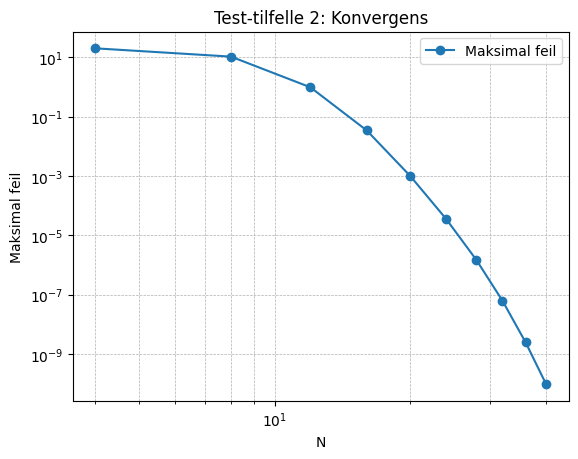

In [12]:
# Definerer funksjoner og verdier for første test-tilfelle
def U2_exact(x, y):
    return np.exp(np.sin(x)**2 + np.cos(2*y))

c2 = 0
Ns = np.arange(4, 44, 4)

errors = []
hs = []

for N in Ns:
    x, y = np.linspace(0, 2*np.pi, N, endpoint=False), np.linspace(0, 4*np.pi, 2*N, endpoint=False)
    X, Y = np.meshgrid(x, y)

    F2_funco = lambda X, Y: F2_func(X, Y, c2)
    F2_numeric = F2_funco(X, Y)

    U2_numeric = biharmonic_solver(X, Y, F2_numeric, c2, np.mean(U2_exact(X, Y)))

    max_error = np.max(np.abs(U2_numeric - U2_exact(X, Y)))         # Beregner feilen mellom numerisk og eksakt løsning         
    errors.append(max_error)
    hs.append(2*np.pi / N)

# Beregner EOC
eocs = []

for i in range(1, len(errors)):
    eoc = np.log(errors[i] / errors[i-1]) / np.log(hs[i] / hs[i-1])
    eocs.append(eoc)

# Printer resultater i tabell
print("\nKonvergenstabell, testtilfelle 2:")
print(f"{'N':<10}{'Max Error':<20}{'EOC':<10}")
print("-" * 40)
for i, N in enumerate(Ns):
    if i == 0:
        print(f"{N:<10}{errors[i]:<20.2e}{'-':<10}")
    else:
        print(f"{N:<10}{errors[i]:<20.2e}{eocs[i-1]:<10.2f}")


# Plotter maksimal feil som funksjon av grid-størrelse
plt.figure()
plt.loglog(Ns, errors, marker='o', label='Maksimal feil')
plt.xlabel('N')
plt.ylabel('Maksimal feil')
plt.title('Test-tilfelle 2: Konvergens')
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.show()

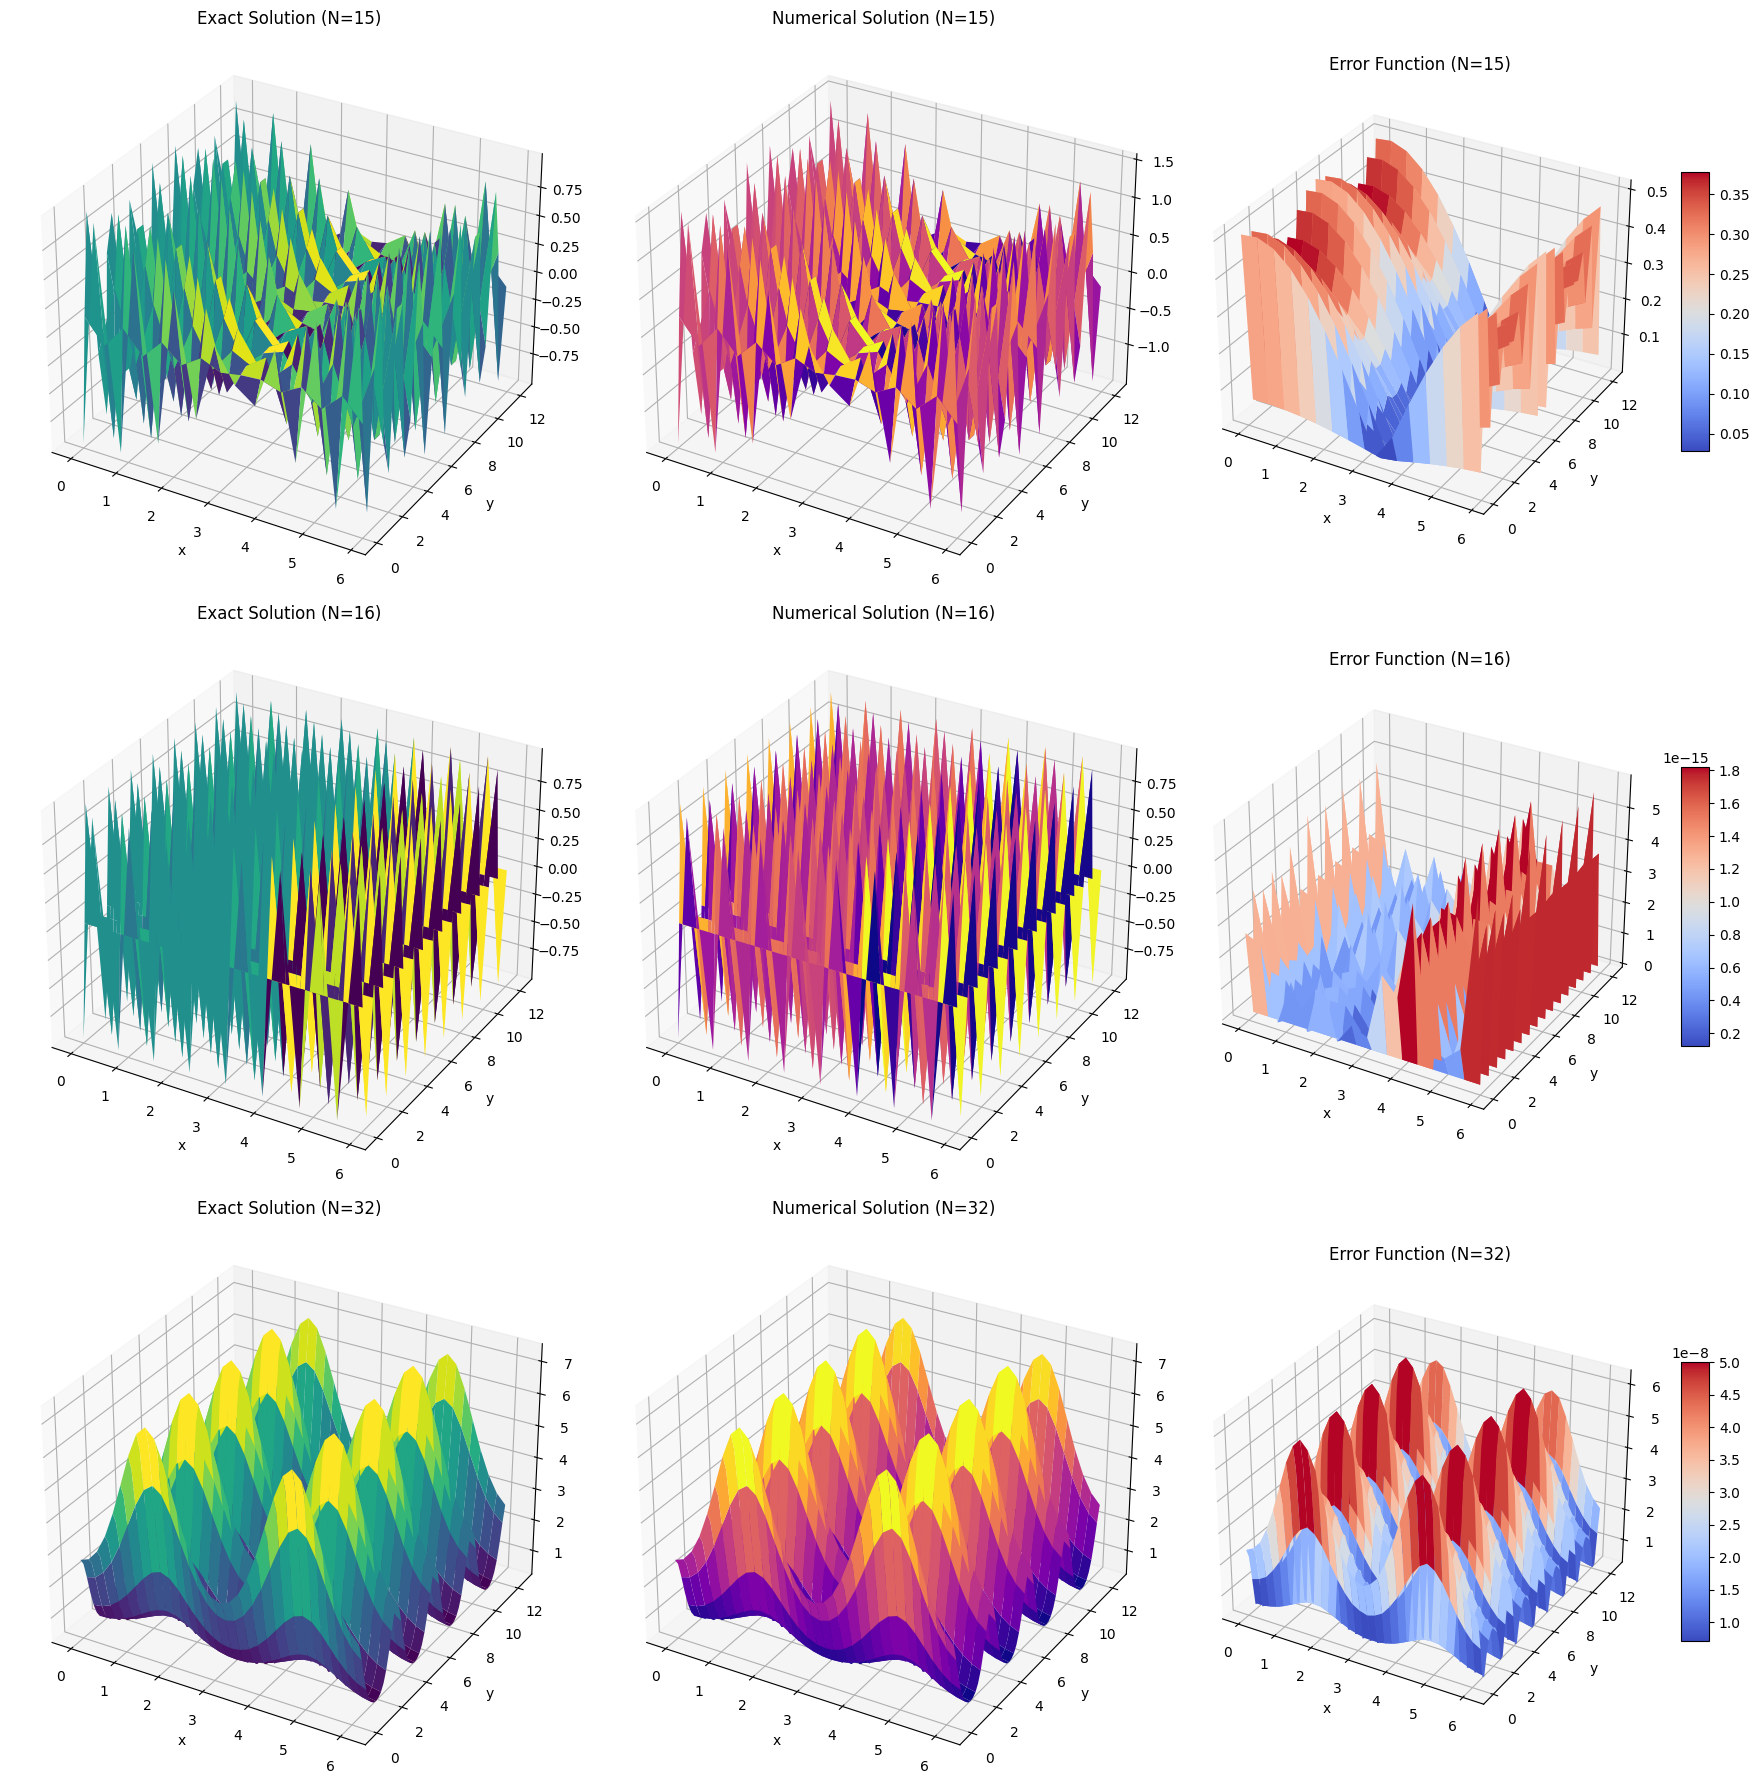

In [18]:
# Define the grid and compute solutions for N = 15, 16 (first series) and N = 32 (second series)
N_values = [15, 16, 32]
solutions = []

for N in N_values:
    x = np.linspace(0, 2 * np.pi, N, endpoint=False)
    y = np.linspace(0, 4 * np.pi, 2 * N, endpoint=False)
    X, Y = np.meshgrid(x, y)

    if N in [15, 16]:  # First series
        F1_numeric = F1_func(X, Y, c1)
        U1_numeric = biharmonic_solver(X, Y, F1_numeric, c1)
        U1_exact_vals = U1_exact(X, Y)
        error1 = np.abs(U1_numeric - U1_exact_vals)
        solutions.append((X, Y, U1_exact_vals, U1_numeric, error1))
    elif N == 32:  # Second series
        F2_numeric = F2_func(X, Y, c2)
        U2_numeric = biharmonic_solver(X, Y, F2_numeric, c2, np.mean(U2_exact(X, Y)))
        U2_exact_vals = U2_exact(X, Y)
        error2 = np.abs(U2_numeric - U2_exact_vals)
        solutions.append((X, Y, U2_exact_vals, U2_numeric, error2))

# Plot the solutions
fig = plt.figure(figsize=(18, 18))

for i, (X, Y, exact, numeric, error) in enumerate(solutions):
    ax1 = fig.add_subplot(3, 3, 3 * i + 1, projection='3d')
    surf1 = ax1.plot_surface(X, Y, exact, cmap='viridis', edgecolor='none')
    ax1.set_title(f'Exact Solution (N={N_values[i]})')
    ax1.set_xlabel('x')
    ax1.set_ylabel('y')

    ax2 = fig.add_subplot(3, 3, 3 * i + 2, projection='3d')
    surf2 = ax2.plot_surface(X, Y, numeric, cmap='plasma', edgecolor='none')
    ax2.set_title(f'Numerical Solution (N={N_values[i]})')
    ax2.set_xlabel('x')
    ax2.set_ylabel('y')

    ax3 = fig.add_subplot(3, 3, 3 * i + 3, projection='3d')
    surf3 = ax3.plot_surface(X, Y, error, cmap='coolwarm', edgecolor='none')
    ax3.set_title(f'Error Function (N={N_values[i]})')
    ax3.set_xlabel('x')
    ax3.set_ylabel('y')
    fig.colorbar(surf3, ax=ax3, shrink=0.5, aspect=10)  # Add colorbar for the error plot

plt.tight_layout()
plt.show()
